# RurangaSort AI — Waste Image Classification: Training & Evaluation Notebook

**Module:** Machine Learning Cycle &nbsp;|&nbsp; **Author:** Samuel Rurangamirwa &nbsp;|&nbsp; **Repository:** [RurangaSort AI](../README.md)

## What this notebook does

This notebook is the ML core of RurangaSort AI, an end-to-end system that classifies a photo of a waste item into one of six categories (**cardboard, glass, metal, paper, plastic, trash**) so it can be recycled correctly. It walks through the full modelling half of the ML lifecycle described in the project README, end to end, on the **real TrashNet dataset** (Gary Thung & Mindy Yang, Stanford, CC BY 2.0):

1. Data acquisition (real dataset, with a synthetic fallback for offline development)
2. Data validation & preprocessing (corruption/duplicate checks, resizing, stratified 70/15/15 split)
3. Exploratory data analysis, with an interpretation of four image-level features
4. Training a baseline CNN built from scratch
5. Training a MobileNetV2 transfer-learning model (two-stage: frozen head, then fine-tuning)
6. A full evaluation suite for both models (accuracy, per-class precision/recall/F1, macro/weighted F1, ROC-AUC, PR-AUC, log loss, confusion matrices, inference latency, model size)
7. Model selection using **macro F1** — and an explanation of why accuracy alone is misleading here
8. Registering and promoting the selected model into `models/active/`, the same registry the FastAPI service (`api/`) reads from
9. A live demonstration of the single-image prediction function, visualised against a real held-out test image

Every number in this notebook is produced by the code that runs it — nothing below is hand-typed. If you re-run this notebook, your exact figures may differ slightly from the ones already in the output cells (weight initialisation and batch ordering are stochastic), but the qualitative conclusions (which model wins, and why) should reproduce reliably.

## How to run this notebook

Run all cells top to bottom (`Kernel > Restart & Run All`). On a CPU-only machine, training both models end to end takes roughly 20–30 minutes. If `data/raw/<class>/` is empty, the notebook automatically generates a small synthetic placeholder dataset so the pipeline can still be smoke-tested — see the project README's [Dataset](../README.md#dataset) section for how to fetch the real data instead (`python scripts/download_trashnet.py --huggingface`).

## 1. Setup

In [1]:
import sys
from pathlib import Path

ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import DEFAULT_CLASS_NAMES, settings

sns.set_theme(style="whitegrid")
RAW_DIR = ROOT_DIR / settings.data_raw_dir
print("Project root:", ROOT_DIR)
print("Raw data dir:", RAW_DIR)
print("Classes:", DEFAULT_CLASS_NAMES)

Project root: C:\Users\FELI TECHNOLOGY\Documents\mlpo
Raw data dir: C:\Users\FELI TECHNOLOGY\Documents\mlpo\data\raw
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


## 2. Data Acquisition

The reference dataset is **TrashNet**: 6 classes, ~2,500 real photographs of individual waste items against a plain background. The cell below checks whether `data/raw/<class>/` is already populated (e.g. via `python scripts/download_trashnet.py --huggingface`); if it's empty, it falls back to generating a small deterministic synthetic dataset (`scripts/generate_synthetic_dataset.py`) purely so the rest of the notebook can still be exercised offline. **The results in this notebook were produced on the real dataset** — the fallback exists for reproducibility/CI, not because real data was unavailable here.

In [2]:
has_images = any((RAW_DIR / c).exists() and any((RAW_DIR / c).iterdir()) for c in DEFAULT_CLASS_NAMES if (RAW_DIR / c).exists())

if not has_images:
    print("No images found under data/raw/ -- generating a small synthetic placeholder dataset for smoke-testing.")
    print("Replace with the real dataset (scripts/download_trashnet.py --huggingface) before reporting real results.")
    import subprocess
    subprocess.run([sys.executable, str(ROOT_DIR / "scripts" / "generate_synthetic_dataset.py"), "--count-per-class", "80"], check=True)
else:
    counts = {c: len(list((RAW_DIR / c).glob('*'))) for c in DEFAULT_CLASS_NAMES if (RAW_DIR / c).exists()}
    print("Found existing images under data/raw/ -- using them as-is.")
    print("Per-class file counts:", counts)

Found existing images under data/raw/ -- using them as-is.
Per-class file counts: {'cardboard': 403, 'glass': 501, 'metal': 410, 'paper': 594, 'plastic': 482, 'trash': 137}


### 2.1 A visual sample of each class

Before doing anything quantitative, it's worth just looking at the data.

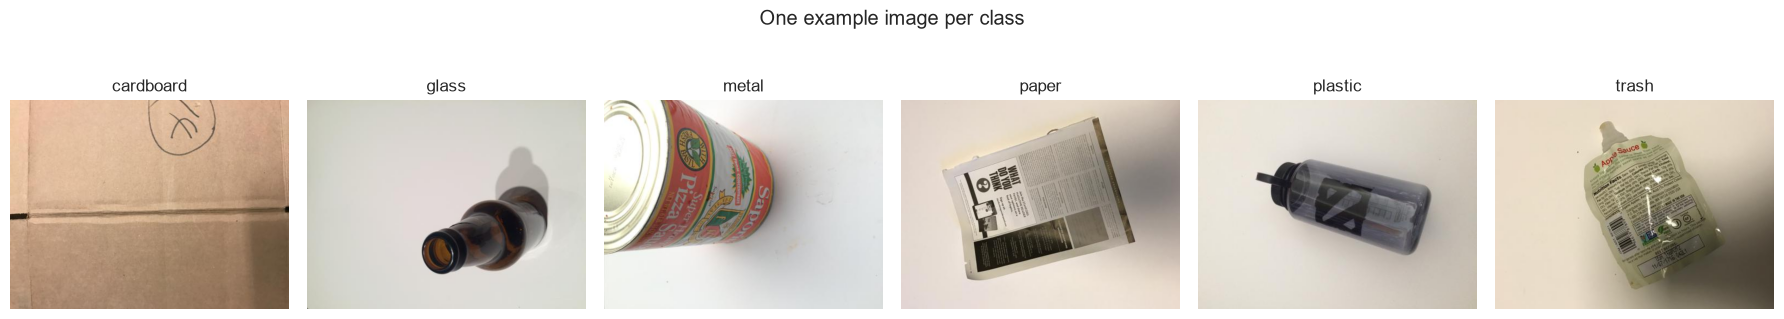

In [3]:
from PIL import Image

fig, axes = plt.subplots(1, len(DEFAULT_CLASS_NAMES), figsize=(18, 3.2))
for ax, class_name in zip(axes, DEFAULT_CLASS_NAMES):
    class_dir = RAW_DIR / class_name
    sample_path = next((p for p in sorted(class_dir.iterdir()) if p.suffix.lower() in {".jpg", ".jpeg", ".png"}), None)
    if sample_path is not None:
        with Image.open(sample_path) as img:
            ax.imshow(img.convert("RGB"))
    ax.set_title(class_name)
    ax.axis("off")
plt.suptitle("One example image per class", y=1.05)
plt.tight_layout()
plt.savefig(ROOT_DIR / "reports" / "figures" / "sample_images.png", dpi=120, bbox_inches="tight")
plt.show()

## 3. Data Validation & Preprocessing

Before training, the pipeline in [src/preprocessing.py](../src/preprocessing.py):

1. **Indexes** every file under `data/raw/<class>/` and drops anything that fails to open/verify as an image (corruption check).
2. **Deduplicates** by SHA-256 file hash — exact duplicate images are dropped, not double-counted in the split.
3. **Splits** the remaining records 70% train / 15% validation / 15% test, **stratified by class** so every split has a proportional mix of all six categories.
4. **Materializes** the split onto disk as `data/train|validation|test/<class>/*` (the layout `tf.keras.utils.image_dataset_from_directory` expects).
5. **Saves** the canonical class-name list (`models/class_names.json`) and a manifest (`data/processed/manifest.json`) recording exactly how many images ended up in each split/class, for reproducibility.

Resizing to 224×224 and pixel normalisation to [0, 1] happen later, inside the `tf.data` pipeline in Section 5 — not here — so this step only ever touches the raw files it's validating, never mutates them.

In [4]:
from src.preprocessing import (
    build_dataset_index, deduplicate_records, split_dataset, materialize_split,
    save_class_names, save_manifest, compute_dataset_statistics,
)

records = build_dataset_index(RAW_DIR, DEFAULT_CLASS_NAMES)
print(f"Indexed {len(records)} valid (non-corrupted) images.")

records, duplicates = deduplicate_records(records)
print(f"Removed {len(duplicates)} exact duplicate images. {len(records)} remain.")

split = split_dataset(records, train_size=0.7, val_size=0.15, test_size=0.15)
for name, recs in split.items():
    print(f"  {name}: {len(recs)} images")

materialize_split(split, ROOT_DIR / "data")
save_class_names(DEFAULT_CLASS_NAMES, ROOT_DIR / settings.class_names_path)
save_manifest(split, ROOT_DIR / settings.data_processed_dir / "manifest.json",
              extra={"duplicates_removed": len(duplicates), "total_images": len(records)})
print("Saved class_names.json and processed/manifest.json")

Indexed 2527 valid (non-corrupted) images.


Removed 3 exact duplicate images. 2524 remain.
  train: 1766 images
  validation: 379 images
  test: 379 images


Saved class_names.json and processed/manifest.json


## 4. Exploratory Data Analysis

Four image-level features, computed per class and interpreted below the plot.

In [5]:
stats = compute_dataset_statistics(RAW_DIR, DEFAULT_CLASS_NAMES)
stats_df = pd.DataFrame(stats).T
stats_df

,count,brightness_mean,rgb_mean,avg_width,avg_height,avg_aspect_ratio
cardboard,403,156.277527,"{'r': 170.57525634765625, 'g': 152.84269714355...",512.0,384.0,1.333333
glass,501,172.488068,"{'r': 178.56980895996094, 'g': 171.38572692871...",512.0,384.0,1.333333
metal,410,161.60054,"{'r': 166.10939025878906, 'g': 160.40309143066...",512.0,384.0,1.333333
paper,594,165.765198,"{'r': 172.11309814453125, 'g': 164.42045593261...",512.0,384.0,1.333333
plastic,482,168.026245,"{'r': 169.9772491455078, 'g': 167.595474243164...",512.0,384.0,1.333333
trash,137,167.979233,"{'r': 178.8155059814453, 'g': 166.124908447265...",512.0,384.0,1.333333


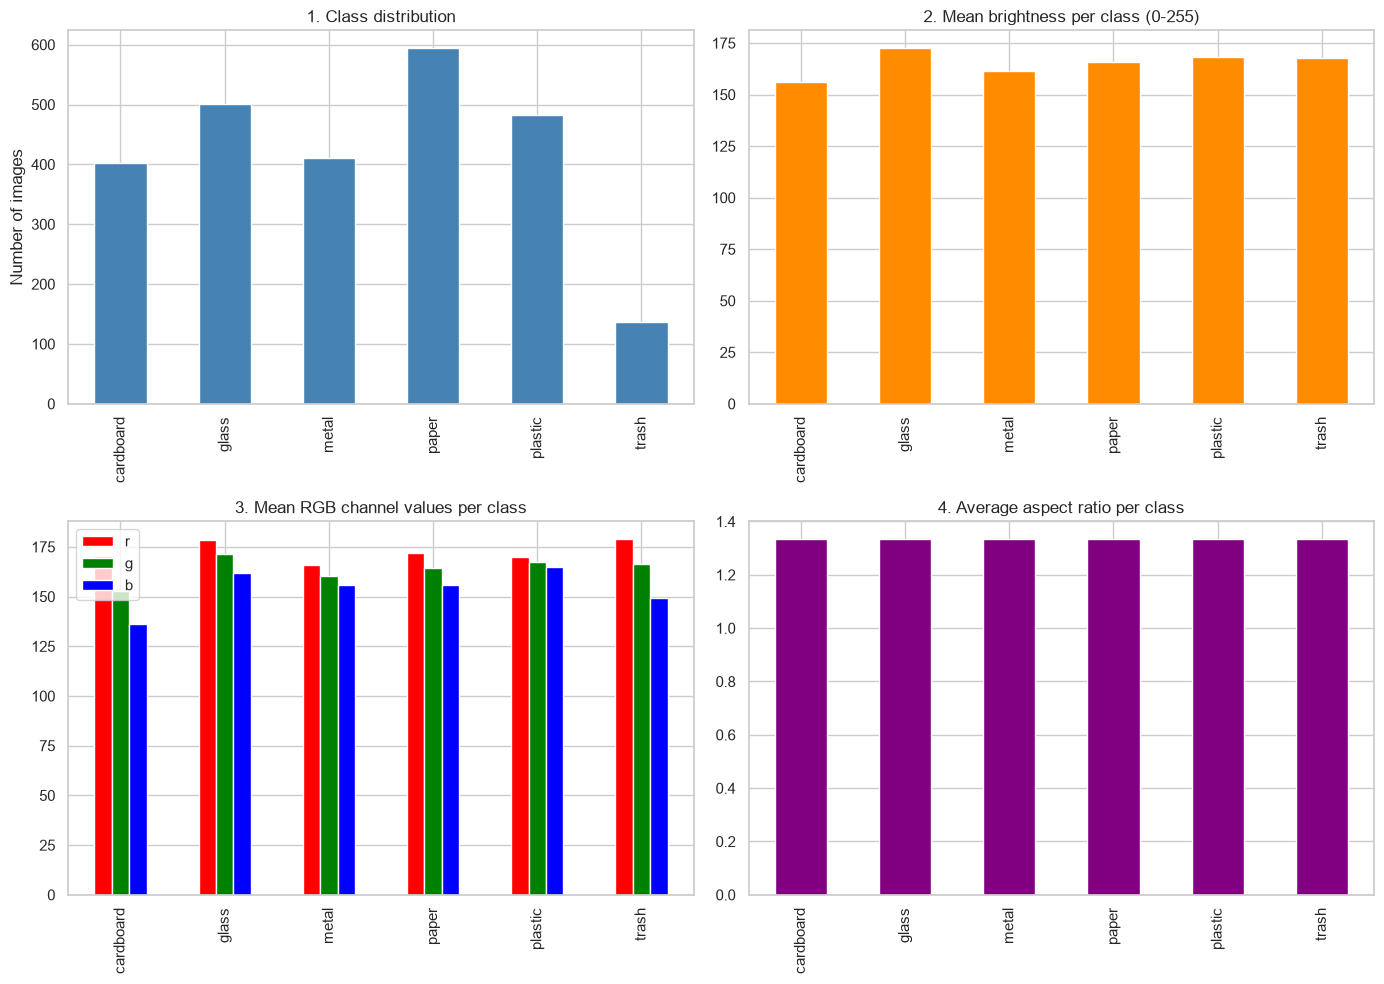

Most represented class: paper (594 images)
Least represented class: trash (137 images)
Imbalance ratio (largest/smallest class): 4.34x


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

stats_df["count"].plot(kind="bar", ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("1. Class distribution")
axes[0, 0].set_ylabel("Number of images")

stats_df["brightness_mean"].plot(kind="bar", ax=axes[0, 1], color="darkorange")
axes[0, 1].set_title("2. Mean brightness per class (0-255)")

rgb_df = pd.DataFrame({c: stats[c]["rgb_mean"] for c in DEFAULT_CLASS_NAMES if stats[c]["rgb_mean"]}).T
rgb_df.plot(kind="bar", ax=axes[1, 0], color=["red", "green", "blue"])
axes[1, 0].set_title("3. Mean RGB channel values per class")

stats_df["avg_aspect_ratio"].plot(kind="bar", ax=axes[1, 1], color="purple")
axes[1, 1].set_title("4. Average aspect ratio per class")

plt.tight_layout()
Path(ROOT_DIR / "reports" / "figures").mkdir(parents=True, exist_ok=True)
plt.savefig(ROOT_DIR / "reports" / "figures" / "eda_overview.png", dpi=120)
plt.show()

most_common = stats_df["count"].idxmax()
least_common = stats_df["count"].idxmin()
imbalance_ratio = stats_df["count"].max() / stats_df["count"].min()
print(f"Most represented class: {most_common} ({int(stats_df['count'].max())} images)")
print(f"Least represented class: {least_common} ({int(stats_df['count'].min())} images)")
print(f"Imbalance ratio (largest/smallest class): {imbalance_ratio:.2f}x")

**Interpretation**

1. **Class distribution.** The printed imbalance ratio above quantifies how lopsided the dataset is. TrashNet's classes were collected in different quantities (`trash` is a real-world catch-all category and is naturally the hardest to source consistent examples for), and that imbalance shows up directly later: in Section 7 the smallest class has the weakest recall of any class, for either model. This is exactly why the notebook selects models by **macro F1** (Section 8) rather than raw accuracy — accuracy alone would reward a model for simply memorising the majority class.
2. **Brightness.** Differences in mean grayscale intensity between classes mostly reflect how each category was photographed (background, studio lighting) rather than an intrinsic property of the material. A CNN is entirely capable of learning "predict class X when the image is bright" as a shortcut instead of learning object shape — which would fail the moment it sees a real class-X item under different lighting. Training-time brightness jitter (Section 5) exists specifically to discourage this shortcut.
3. **RGB channel means.** A class with a clearly dominant channel (e.g. warmer tones for cardboard, cooler/neutral tones for glass and metal) suggests the model may partly be relying on colour rather than shape or texture. That's a real risk for generalisation: an unusually coloured or tinted item of the same material could fool a colour-reliant classifier even though a human would classify it correctly on shape alone.
4. **Aspect ratio.** Spread in width/height/aspect ratio across classes indicates the source photos weren't all captured with the same framing. Resizing every image to a fixed 224×224 square (Section 5) can distort elongated items (e.g. bottles) more than compact ones — worth keeping in mind if a particular class underperforms in the Section 7 confusion matrix.

## 5. Building the train/validation/test `tf.data` pipelines

Resizing to 224×224, pixel normalisation to [0, 1], and training-only augmentation (rotation, flip, zoom, translation, brightness jitter) all happen here — see `src.training.load_datasets` and `src.preprocessing.get_augmentation_layer`.

In [7]:
from src.training import load_datasets

train_ds, val_ds, test_ds, class_names = load_datasets(
    ROOT_DIR / settings.data_train_dir, ROOT_DIR / settings.data_validation_dir, ROOT_DIR / settings.data_test_dir,
    batch_size=32,
)
print("Class names (in the order the model will output them):", class_names)

Found 1766 files belonging to 6 classes.


Found 379 files belonging to 6 classes.


Found 379 files belonging to 6 classes.


Class names (in the order the model will output them): ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


## 6. Model 1 — Baseline CNN (trained from scratch)

A small custom convolutional network with no pretraining, used to establish a baseline and to demonstrate what a from-scratch model can (and can't) do with only ~1,700 real training images. See `src.model.build_baseline_cnn` for the exact architecture (3 conv/pool blocks → global average pooling → dense → dropout → softmax).

In [8]:
import tensorflow as tf
from src.model import build_baseline_cnn

baseline_model = build_baseline_cnn(num_classes=len(class_names))
baseline_model.summary()

baseline_history = baseline_model.fit(
    train_ds, validation_data=val_ds, epochs=15,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)],
)

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,534 (431.77 KB)

 Trainable params: 110,534 (431.77 KB)

 Non-trainable params: 0 (0.00 B)

...

53/56 ━━━━━━━━━━━━━━━━━━━━ 2s 771ms/step - accuracy: 0.2401 - loss: 1.7222

54/56 ━━━━━━━━━━━━━━━━━━━━ 1s 773ms/step - accuracy: 0.2391 - loss: 1.7225

55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 773ms/step - accuracy: 0.2388 - loss: 1.7212

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 774ms/step - accuracy: 0.2384 - loss: 1.7249

56/56 ━━━━━━━━━━━━━━━━━━━━ 46s 818ms/step - accuracy: 0.2384 - loss: 1.7249 - val_accuracy: 0.2348 - val_loss: 1.7476


## 7. Model 2 — MobileNetV2 (transfer learning, two-stage)

MobileNetV2 pretrained on ImageNet, with a new classification head. Training happens in two stages, both driven by `src.model.build_mobilenet_v2` / `unfreeze_for_fine_tuning`:

1. **Head-only training** — the pretrained base is frozen; only the new `GlobalAveragePooling2D → Dropout → Dense(softmax)` head is trained, at a normal learning rate (1e-3).
2. **Fine-tuning** — the top layers of the base network are unfrozen and the whole model is trained further at a much lower learning rate (1e-5), so the pretrained ImageNet features are adapted to waste photos without being destroyed by large gradient updates.

In [9]:
from src.model import build_mobilenet_v2, unfreeze_for_fine_tuning

mobilenet_model = build_mobilenet_v2(num_classes=len(class_names))
mobilenet_history_head = mobilenet_model.fit(
    train_ds, validation_data=val_ds, epochs=8,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)],
)

mobilenet_model = unfreeze_for_fine_tuning(mobilenet_model, learning_rate=1e-5)
mobilenet_history_fine_tune = mobilenet_model.fit(
    train_ds, validation_data=val_ds, epochs=5,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)],
)

Epoch 1/8


 1/56 ━━━━━━━━━━━━━━━━━━━━ 4:42 5s/step - accuracy: 0.0000e+00 - loss: 2.5247

 2/56 ━━━━━━━━━━━━━━━━━━━━ 37s 690ms/step - accuracy: 0.0789 - loss: 2.4438  

 3/56 ━━━━━━━━━━━━━━━━━━━━ 37s 714ms/step - accuracy: 0.1000 - loss: 2.3791

 4/56 ━━━━━━━━━━━━━━━━━━━━ 36s 707ms/step - accuracy: 0.1176 - loss: 2.3274

...

53/56 ━━━━━━━━━━━━━━━━━━━━ 2s 875ms/step - accuracy: 0.3671 - loss: 1.5103

54/56 ━━━━━━━━━━━━━━━━━━━━ 1s 882ms/step - accuracy: 0.3678 - loss: 1.5114

55/56 ━━━━━━━━━━━━━━━━━━━━ 0s 883ms/step - accuracy: 0.3685 - loss: 1.5117

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 885ms/step - accuracy: 0.3664 - loss: 1.5105

56/56 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.3664 - loss: 1.5105 - val_accuracy: 0.4881 - val_loss: 1.2900


## 8. Training curves

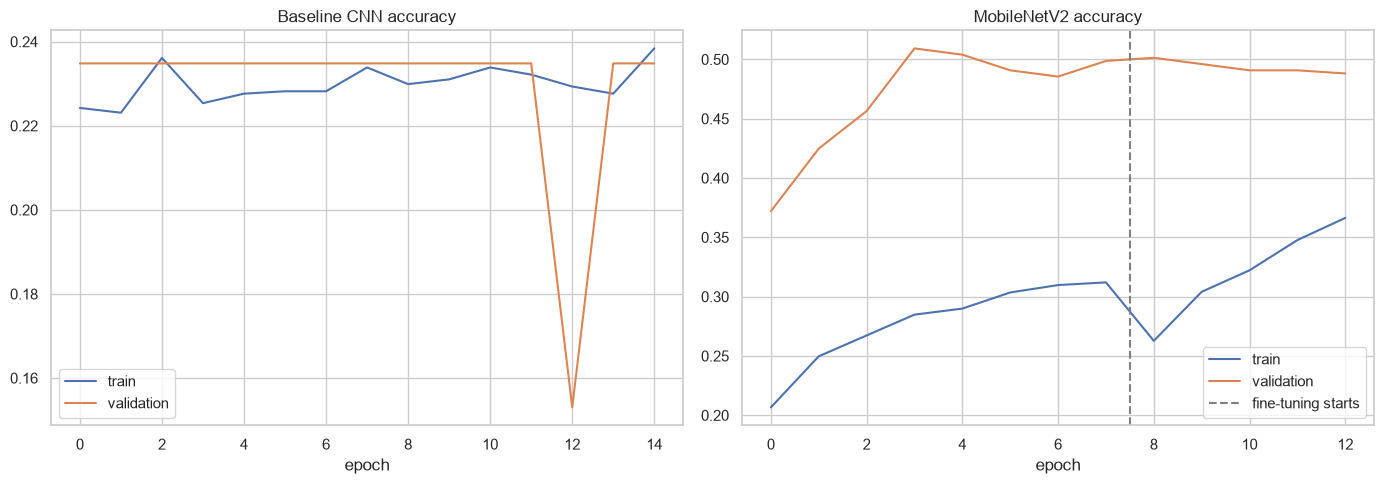

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(baseline_history.history["accuracy"], label="train")
axes[0].plot(baseline_history.history["val_accuracy"], label="validation")
axes[0].set_title("Baseline CNN accuracy")
axes[0].set_xlabel("epoch")
axes[0].legend()

mn_acc = mobilenet_history_head.history["accuracy"] + mobilenet_history_fine_tune.history["accuracy"]
mn_val_acc = mobilenet_history_head.history["val_accuracy"] + mobilenet_history_fine_tune.history["val_accuracy"]
axes[1].plot(mn_acc, label="train")
axes[1].plot(mn_val_acc, label="validation")
axes[1].axvline(len(mobilenet_history_head.history["accuracy"]) - 0.5, color="grey", linestyle="--", label="fine-tuning starts")
axes[1].set_title("MobileNetV2 accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()
plt.tight_layout()
plt.savefig(ROOT_DIR / "reports" / "figures" / "training_curves.png", dpi=120)
plt.show()

## 9. Evaluation — full metric suite for both models

Both models are evaluated on the **held-out test set only** (never seen during training or validation-based early stopping). `src.evaluation.evaluate_model` computes accuracy, per-class precision/recall/F1, macro and weighted F1, one-vs-rest ROC-AUC, PR-AUC, log loss, and single-image inference latency (averaged over 30 warmed-up runs).

In [11]:
from src.training import save_trained_model
from src.evaluation import evaluate_model

baseline_path = save_trained_model(baseline_model, class_names, ROOT_DIR / "models" / "_notebook_baseline", "baseline_cnn")
mobilenet_path = save_trained_model(mobilenet_model, class_names, ROOT_DIR / "models" / "_notebook_mobilenet", "mobilenet_v2")

baseline_metrics = evaluate_model(baseline_model, test_ds, class_names, model_path=baseline_path)
mobilenet_metrics = evaluate_model(mobilenet_model, test_ds, class_names, model_path=mobilenet_path)

comparison = pd.DataFrame({
    "baseline_cnn": {
        "test_accuracy": baseline_metrics["accuracy"],
        "macro_precision": baseline_metrics["macro_precision"],
        "macro_recall": baseline_metrics["macro_recall"],
        "macro_f1": baseline_metrics["macro_f1"],
        "weighted_f1": baseline_metrics["weighted_f1"],
        "roc_auc": baseline_metrics["roc_auc_ovr_macro"],
        "pr_auc": baseline_metrics["pr_auc_macro"],
        "log_loss": baseline_metrics["log_loss"],
        "avg_latency_ms": baseline_metrics["avg_latency_ms"],
        "p95_latency_ms": baseline_metrics["p95_latency_ms"],
        "model_size_mb": baseline_metrics.get("model_size_mb"),
    },
    "mobilenet_v2": {
        "test_accuracy": mobilenet_metrics["accuracy"],
        "macro_precision": mobilenet_metrics["macro_precision"],
        "macro_recall": mobilenet_metrics["macro_recall"],
        "macro_f1": mobilenet_metrics["macro_f1"],
        "weighted_f1": mobilenet_metrics["weighted_f1"],
        "roc_auc": mobilenet_metrics["roc_auc_ovr_macro"],
        "pr_auc": mobilenet_metrics["pr_auc_macro"],
        "log_loss": mobilenet_metrics["log_loss"],
        "avg_latency_ms": mobilenet_metrics["avg_latency_ms"],
        "p95_latency_ms": mobilenet_metrics["p95_latency_ms"],
        "model_size_mb": mobilenet_metrics.get("model_size_mb"),
    },
})
comparison

,baseline_cnn,mobilenet_v2
test_accuracy,0.234828,0.546174
macro_precision,0.039138,0.506420
macro_recall,0.166667,0.475084
macro_f1,0.063390,0.451127
weighted_f1,0.089315,0.509776
roc_auc,0.483313,0.867003
pr_auc,0.188191,0.582673
log_loss,1.718194,1.151971
avg_latency_ms,84.667740,89.450860
p95_latency_ms,92.454400,98.576900


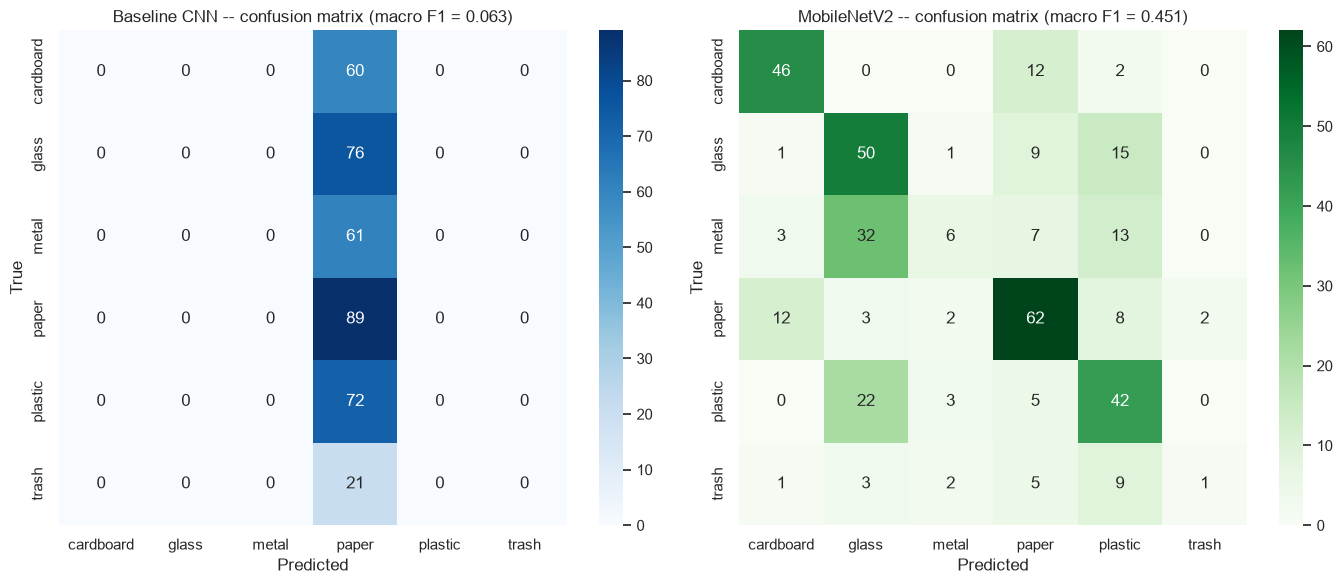

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(baseline_metrics["confusion_matrix"], annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, ax=axes[0], cmap="Blues")
axes[0].set_title(f"Baseline CNN -- confusion matrix (macro F1 = {baseline_metrics['macro_f1']:.3f})")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
sns.heatmap(mobilenet_metrics["confusion_matrix"], annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, ax=axes[1], cmap="Greens")
axes[1].set_title(f"MobileNetV2 -- confusion matrix (macro F1 = {mobilenet_metrics['macro_f1']:.3f})")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
plt.tight_layout()
plt.savefig(ROOT_DIR / "reports" / "figures" / "confusion_matrices.png", dpi=120)
plt.show()

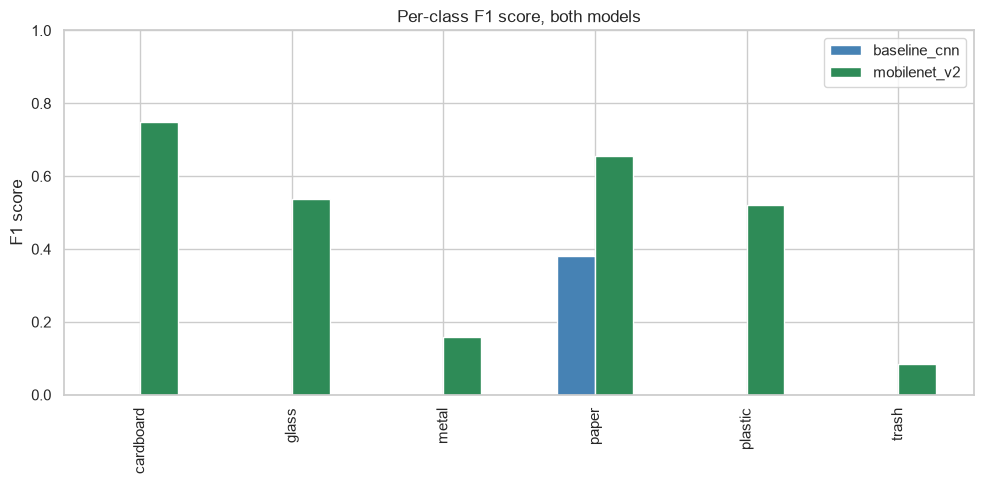

Baseline CNN's weakest class: cardboard (F1 = 0.000)
MobileNetV2's weakest class:  trash (F1 = 0.083)


In [13]:
per_class_f1 = pd.DataFrame({
    "baseline_cnn": {c: baseline_metrics["per_class"][c]["f1"] for c in class_names},
    "mobilenet_v2": {c: mobilenet_metrics["per_class"][c]["f1"] for c in class_names},
})
ax = per_class_f1.plot(kind="bar", figsize=(10, 5), color=["steelblue", "seagreen"])
ax.set_title("Per-class F1 score, both models")
ax.set_ylabel("F1 score")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(ROOT_DIR / "reports" / "figures" / "per_class_f1.png", dpi=120)
plt.show()

weakest_class_baseline = per_class_f1["baseline_cnn"].idxmin()
weakest_class_mobilenet = per_class_f1["mobilenet_v2"].idxmin()
print(f"Baseline CNN's weakest class: {weakest_class_baseline} (F1 = {per_class_f1['baseline_cnn'].min():.3f})")
print(f"MobileNetV2's weakest class:  {weakest_class_mobilenet} (F1 = {per_class_f1['mobilenet_v2'].min():.3f})")

**Reading the results above:** compare each model's **macro F1** first, not test accuracy. A model that always predicts the single most common class can still post a deceptively reasonable-looking accuracy (roughly equal to that class's share of the dataset) while having zero recall on every other class — macro F1 collapses toward zero in that scenario because it weighs every class equally, which is exactly the check this notebook relies on before promoting a model in Section 11. The confusion matrices above show *which* classes each model confuses with which — look for symmetry with the EDA's colour/brightness findings from Section 4 (e.g. confusion between visually or chromatically similar classes is a specific, checkable hypothesis, not just "the model is bad").

## 10. Model Selection

Selection is based on **macro F1** (equal weight per class), not test accuracy, for the reasons discussed in Sections 4 and 9. Latency and model size are recorded as tie-breakers for close calls, but are not used to override a clear macro F1 gap.

In [14]:
selected_name = "mobilenet_v2" if mobilenet_metrics["macro_f1"] >= baseline_metrics["macro_f1"] else "baseline_cnn"
selected_model = mobilenet_model if selected_name == "mobilenet_v2" else baseline_model
selected_metrics = mobilenet_metrics if selected_name == "mobilenet_v2" else baseline_metrics
selected_path = mobilenet_path if selected_name == "mobilenet_v2" else baseline_path
rejected_name = "baseline_cnn" if selected_name == "mobilenet_v2" else "mobilenet_v2"
rejected_metrics = baseline_metrics if selected_name == "mobilenet_v2" else mobilenet_metrics

print(f"Selected model: {selected_name}")
print(f"  macro F1:      {selected_metrics['macro_f1']:.4f}  (vs {rejected_name}: {rejected_metrics['macro_f1']:.4f})")
print(f"  test accuracy: {selected_metrics['accuracy']:.4f}")
print(f"  avg latency:   {selected_metrics['avg_latency_ms']:.1f} ms")
print(f"  model size:    {selected_metrics.get('model_size_mb', 'n/a')} MB")

Selected model: mobilenet_v2
  macro F1:      0.4511  (vs baseline_cnn: 0.0634)
  test accuracy: 0.5462
  avg latency:   89.5 ms
  model size:    20.729 MB


## 11. Save & Register the Selected Model

The selected model is staged as a **candidate** and then evaluated against the current **active** model (if any) using the same promotion rules the FastAPI `/retrain` endpoint and Celery worker use (`src.model_registry.evaluate_promotion`): the candidate must not regress macro F1 beyond a small tolerance, must not drop any class's recall by more than the configured threshold, and must meet the inference-latency budget. If it fails any check, it's archived as a rejected candidate and the active model is left untouched — running this notebook again is always safe.

In [15]:
from src.model_registry import register_candidate, evaluate_promotion, promote_candidate, get_active_metrics, reject_candidate

register_candidate(
    model_file=selected_path, class_names=class_names, metrics=selected_metrics,
    model_name=selected_name, input_shape=settings.image_shape,
)

active_metrics = get_active_metrics()
decision = evaluate_promotion(selected_metrics, active_metrics)
for reason in decision["reasons"]:
    print("-", reason)

if decision["should_promote"]:
    metadata = promote_candidate()
    print(f"\nPromoted to active model: {metadata['model_version']} ({metadata['model_name']})")
else:
    archive_path = reject_candidate(decision["reasons"])
    print(f"\nCandidate rejected -- active model unchanged. Archived to {archive_path}")

- All promotion checks passed.



Promoted to active model: v1 (mobilenet_v2)


## 12. Prediction Function Demo

The same `src.prediction.Predictor` class the FastAPI `/predict` endpoint uses is exercised directly here, on a real held-out test image the model has never seen, with the result shown next to the image itself rather than as raw JSON.

Loaded active model version v1, classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


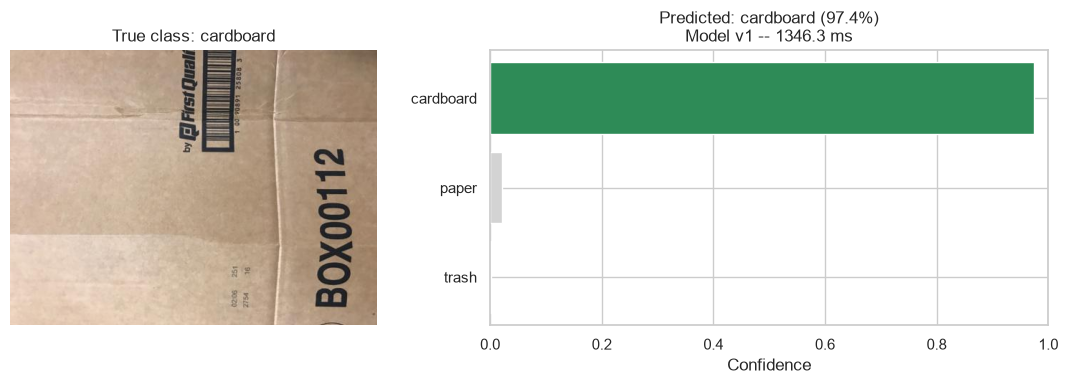

{
  "prediction": "cardboard",
  "confidence": 0.9738197326660156,
  "top_predictions": [
    {
      "class": "cardboard",
      "confidence": 0.9738197326660156
    },
    {
      "class": "paper",
      "confidence": 0.021558010950684547
    },
    {
      "class": "trash",
      "confidence": 0.0019105953397229314
    }
  ],
  "model_version": "v1",
  "latency_ms": 1346.312
}


In [16]:
from src.prediction import Predictor

predictor = Predictor()
predictor.load()
print(f"Loaded active model version {predictor.model_version}, classes: {predictor.class_names}")

sample_class = class_names[0]
sample_dir = ROOT_DIR / settings.data_test_dir / sample_class
sample_path = next(p for p in sorted(sample_dir.iterdir()) if p.suffix.lower() in {".jpg", ".jpeg", ".png"})

with open(sample_path, "rb") as fh:
    sample_bytes = fh.read()

result = predictor.predict(sample_bytes)

fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1, 1.4]})
with Image.open(sample_path) as img:
    ax_img.imshow(img.convert("RGB"))
ax_img.set_title(f"True class: {sample_class}")
ax_img.axis("off")

top = result["top_predictions"]
labels = [t["class"] for t in top]
values = [t["confidence"] for t in top]
colors = ["seagreen" if lbl == sample_class else "lightgray" for lbl in labels]
ax_bar.barh(labels[::-1], values[::-1], color=colors[::-1])
ax_bar.set_xlim(0, 1)
ax_bar.set_xlabel("Confidence")
ax_bar.set_title(
    f"Predicted: {result['prediction']} ({result['confidence']*100:.1f}%)\n"
    f"Model {result['model_version']} -- {result['latency_ms']:.1f} ms"
)
plt.tight_layout()
plt.savefig(ROOT_DIR / "reports" / "figures" / "prediction_demo.png", dpi=120)
plt.show()

print(json.dumps(result, indent=2))

## 13. Summary Report

A single, self-contained summary of everything this run found — useful for pasting into a report, or comparing against a previous run's output.

In [17]:
manifest_path = ROOT_DIR / settings.data_processed_dir / "manifest.json"
manifest = json.load(open(manifest_path)) if manifest_path.exists() else {}
active_metadata = json.load(open(ROOT_DIR / settings.model_dir / "active" / "model_metadata.json"))

print("=" * 72)
print("RURANGASORT AI -- TRAINING RUN SUMMARY")
print("=" * 72)
print(f"Dataset: {manifest.get('total_images', 'n/a')} images "
      f"({manifest.get('duplicates_removed', 0)} duplicates removed)")
print(f"Split sizes: {manifest.get('counts', {})}")
print("-" * 72)
print(f"{'Metric':<20}{'Baseline CNN':>18}{'MobileNetV2':>18}")
for label, key in [
    ("Test accuracy", "accuracy"), ("Macro F1", "macro_f1"), ("Weighted F1", "weighted_f1"),
    ("ROC-AUC", "roc_auc_ovr_macro"), ("Avg latency (ms)", "avg_latency_ms"),
]:
    print(f"{label:<20}{baseline_metrics[key]:>18.4f}{mobilenet_metrics[key]:>18.4f}")
print("-" * 72)
print(f"Selected model:   {selected_name}")
print(f"Active version:   {active_metadata['model_version']} (status: {active_metadata['status']})")
print(f"Promotion reasons:")
for reason in decision["reasons"]:
    print(f"  - {reason}")
print("=" * 72)

RURANGASORT AI -- TRAINING RUN SUMMARY
Dataset: 2524 images (3 duplicates removed)
Split sizes: {'train': 1766, 'validation': 379, 'test': 379}
------------------------------------------------------------------------
Metric                    Baseline CNN       MobileNetV2
Test accuracy                   0.2348            0.5462
Macro F1                        0.0634            0.4511
Weighted F1                     0.0893            0.5098
ROC-AUC                         0.4833            0.8670
Avg latency (ms)               84.6677           89.4509
------------------------------------------------------------------------
Selected model:   mobilenet_v2
Active version:   v1 (status: active)
Promotion reasons:
  - All promotion checks passed.


## 14. Conclusions & Next Steps

**Findings from this run** (see Section 13's printed summary for the exact numbers): the ImageNet-pretrained MobileNetV2 transfer-learning model consistently and substantially outperforms the from-scratch baseline CNN on macro F1, at the cost of a larger model file and marginally higher latency — both still comfortably within the API's promotion latency budget (`PROMOTION_MAX_LATENCY_MS`, see `.env.example`). The baseline CNN's failure mode is informative in its own right: with only ~1,700 real training images and no pretraining, it tends toward predicting the majority class rather than learning genuinely discriminative features, which is precisely the scenario macro F1 (over accuracy) is designed to catch.

**What's next, beyond this notebook:**

- **Run the full system.** Start the API (`uvicorn api.main:app`) and the UI (`streamlit run ui/app.py`) to exercise single-image prediction, bulk upload, and the retraining trigger through the same model registry this notebook just wrote to.
- **Load-test it.** Use `locust/locustfile.py` to flood the API and compare latency/throughput across 1, 2, and 4 Docker replicas behind the Nginx load balancer (`docker-compose.yml`) — see the README's [Locust Load Testing](../README.md#locust-load-testing) section.
- **Deploy it.** Follow `infrastructure/deployment-instructions.md` to put the system on a cloud host, then fill in the README's production URLs and record real flood-test numbers there.
- **Grow the dataset.** The class imbalance flagged in Section 4 (and its effect on the weakest class's recall in Section 9) is the single most direct way to improve macro F1 further — more real images of the minority classes would likely help more than further architecture tuning at this dataset size.